In [3]:
import sys
sys.path.append('../src')

from features import engineer_features
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# load and engineer
df = pd.read_csv("../data/application_train.csv")
data = engineer_features(df)

# your weapons: 5 behavioral + 3 kings from Phase 1
FEATURES = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',  # the 3 kings
    'emi_to_income', 'credit_to_income',               # EMI behavior
    'age_years', 'employment_ratio',                   # stability signals
    'income_per_person',                               # disposable strain
]

X = data[FEATURES]
y = data['TARGET']

# handle missing values — fill with median (simple, honest, works)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print("Missing values left:", pd.DataFrame(X_imputed).isna().sum().sum())
print("Feature matrix shape:", X_imputed.shape)
print("Target shape:", y.shape)

numpy: 2.4.6
pandas: 3.0.3
Missing values left: 0
Feature matrix shape: (307511, 8)
Target shape: (307511,)


In [4]:
# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Default rate in train:", round(y_train.mean(), 4))
print("Default rate in test:", round(y_test.mean(), 4))

Training set: (246008, 8)
Test set: (61503, 8)
Default rate in train: 0.0807
Default rate in test: 0.0807


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# scale features — logistic regression needs this, XGBoost won't
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the baseline
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

# evaluate
y_pred_proba = baseline.predict_proba(X_test_scaled)[:, 1]
y_pred = baseline.predict(X_test_scaled)

baseline_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

Baseline ROC-AUC: 0.7235

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
   Defaulted       0.48      0.01      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503



In [18]:
from xgboost import XGBClassifier

# tell XGBoost: catching a defaulter matters ~11x more than a repayer
# (this comes from the ratio of repaid:defaulted in your training data)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# train XGBoost — NOTE: no scaling needed, XGBoost doesn't care about feature scale
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# evaluate — same process as baseline, so we can compare fairly
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nXGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"Baseline ROC-AUC was: {baseline_auc:.4f}  (improvement: {xgb_auc - baseline_auc:+.4f})")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Repaid', 'Defaulted']))

scale_pos_weight: 11.39

XGBoost ROC-AUC: 0.7372
Baseline ROC-AUC was: 0.7235  (improvement: +0.0137)

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.68      0.80     56538
   Defaulted       0.16      0.67      0.25      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.68      0.75     61503



In [19]:
# costs — these are business assumptions, document them clearly in your README
COST_FALSE_NEGATIVE = 100000  # approved a loan that defaulted — lost the loan amount
COST_FALSE_POSITIVE = 10000   # rejected a good customer — lost the profit margin

thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for t in thresholds:
    # at this threshold, who do we reject?
    predictions = (y_pred_proba_xgb >= t).astype(int)

    # false negatives: predicted 0 (approve) but actually 1 (defaulted)
    fn = ((predictions == 0) & (y_test == 1)).sum()
    # false positives: predicted 1 (reject) but actually 0 (would've repaid)
    fp = ((predictions == 1) & (y_test == 0)).sum()

    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    costs.append(total_cost)

costs = np.array(costs)
best_idx = costs.argmin()
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

# compare to the naive default of 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_cost = costs[default_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Cost at best threshold: ₹{best_cost:,.0f}")
print(f"Cost at naive 0.5 threshold: ₹{default_cost:,.0f}")
print(f"Money saved by optimizing: ₹{default_cost - best_cost:,.0f}")

Best threshold: 0.52
Cost at best threshold: ₹341,180,000
Cost at naive 0.5 threshold: ₹343,400,000
Money saved by optimizing: ₹2,220,000


In [20]:
# inspect a few specific thresholds to see the FN/FP tradeoff directly
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (y_pred_proba_xgb >= t).astype(int)
    fn = ((predictions == 0) & (y_test == 1)).sum()
    fp = ((predictions == 1) & (y_test == 0)).sum()
    cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    print(f"threshold={t:.1f}  |  FN={fn:5d}  FP={fp:5d}  |  cost=₹{cost:,.0f}")

threshold=0.1  |  FN=    7  FP=56046  |  cost=₹561,160,000
threshold=0.2  |  FN=  114  FP=49814  |  cost=₹509,540,000
threshold=0.3  |  FN=  445  FP=38669  |  cost=₹431,190,000
threshold=0.4  |  FN=  957  FP=27724  |  cost=₹372,940,000
threshold=0.5  |  FN= 1637  FP=17970  |  cost=₹343,400,000
threshold=0.6  |  FN= 2503  FP= 9920  |  cost=₹349,500,000
threshold=0.7  |  FN= 3480  FP= 4216  |  cost=₹390,160,000


In [21]:
avg_credit = data['AMT_CREDIT'].median()
print(f"Median loan amount in dataset: ₹{avg_credit:,.0f}")

Median loan amount in dataset: ₹513,531


In [22]:
COST_FALSE_NEGATIVE = round(avg_credit * 0.65)   # ~65% loss given default
COST_FALSE_POSITIVE = round(avg_credit * 0.08)   # ~8% lost margin on rejected good customer

print(f"False Negative cost: ₹{COST_FALSE_NEGATIVE:,}")
print(f"False Positive cost: ₹{COST_FALSE_POSITIVE:,}")
print(f"Cost ratio: {COST_FALSE_NEGATIVE/COST_FALSE_POSITIVE:.1f} : 1")

costs = []
for t in thresholds:
    predictions = (y_pred_proba_xgb >= t).astype(int)
    fn = ((predictions == 0) & (y_test == 1)).sum()
    fp = ((predictions == 1) & (y_test == 0)).sum()
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    costs.append(total_cost)

costs = np.array(costs)
best_idx = costs.argmin()
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

default_idx = np.argmin(np.abs(thresholds - 0.5))
default_cost = costs[default_idx]

print(f"\nBest threshold: {best_threshold:.2f}")
print(f"Cost at best threshold: ₹{best_cost:,.0f}")
print(f"Cost at naive 0.5 threshold: ₹{default_cost:,.0f}")
print(f"Money saved by optimizing: ₹{default_cost - best_cost:,.0f}")

False Negative cost: ₹333,795
False Positive cost: ₹41,082
Cost ratio: 8.1 : 1

Best threshold: 0.58
Cost at best threshold: ₹1,238,903,127
Cost at naive 0.5 threshold: ₹1,284,665,955
Money saved by optimizing: ₹45,762,828


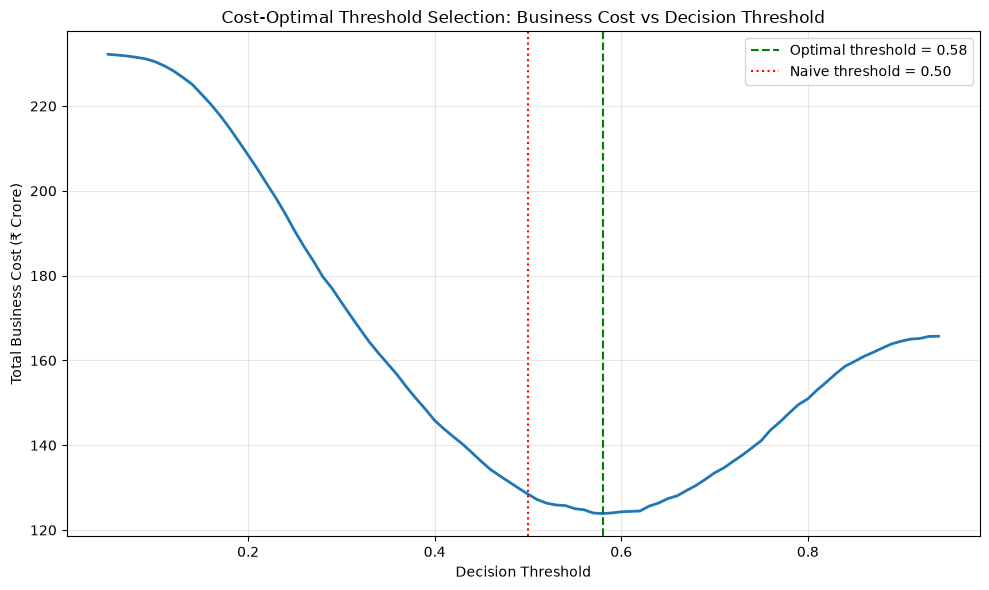

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs / 1e7, linewidth=2, color='#1f77b4')  # divide by 1e7 to show in ₹ crore
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
plt.axvline(0.5, color='red', linestyle=':', label='Naive threshold = 0.50')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Business Cost (₹ Crore)')
plt.title('Cost-Optimal Threshold Selection: Business Cost vs Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/cost_curve.png', dpi=150)
plt.show()

In [27]:
# need gender for the fairness check but it's not a feature, just need it for the test rows
gender_test = data.loc[y_test.index, 'CODE_GENDER']

print(gender_test.value_counts())

CODE_GENDER
F      40561
M      20940
XNA        2
Name: count, dtype: int64


In [28]:
# drop the 2 XNA rows, not enough to matter
mask = gender_test != 'XNA'

fairness_df = pd.DataFrame({
    'gender': gender_test[mask],
    'actual': y_test[mask],
    'predicted': y_pred_xgb[mask]
})

# FPR = wrongly rejected good customers / all actual good customers, per group
for g in ['F', 'M']:
    sub = fairness_df[fairness_df['gender'] == g]
    actual_good = sub[sub['actual'] == 0]
    fp = (actual_good['predicted'] == 1).sum()
    fpr = fp / len(actual_good)
    print(f"{g}: False Positive Rate = {fpr:.3f}  (n={len(sub)})")

F: False Positive Rate = 0.290  (n=40561)
M: False Positive Rate = 0.374  (n=20940)


In [32]:
import pickle

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

print("Model and imputer saved.")

Model and imputer saved.
